# Tarea 1 MAD - Pipeline de Limpieza de Datos

**Estudiante:** Benjamin Enrique Parra Barbet

---

## Resumen Ejecutivo

Este notebook documenta el proceso completo de limpieza y preparacion de datos para análisis.

### Datos Crudos
- **attempts.csv:** 89,229 registros de actividad de estudiantes
- **student_data.csv:** 685 estudiantes con datos demograficos y academicos

### Hallazgos Principales
- 333 estudiantes (48.5%) nunca iniciaron sesion en la plataforma
- 127 estudiantes tienen exam=-1 (no rindieron examen) - codigo de dominio valido
- 5 estudiantes tienen take_exam en blanco pero tienen datos parciales en otras variables
- Blancos distribuidos: gender=49, pretest=47, posttest=252, motivacionales=49

### Transformaciones Clave
- Espacios en blanco -> pd.NA (preserva faltantes reales)
- durationseconds > 300s clippeados a 300 (outliers)
- Engagement = 0 para estudiantes sin actividad (NO NA - es un valor real)
- exam=-1 preservado como -1 (codigo "no rindio", no error)

### Output Final
- **data_prep.csv:** 685 filas, 20 columnas
- **Graficos:** distribucion por grupo social (social=0 vs social=1)

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

## PASO 1: Cargar Datos Crudos

In [ ]:
# Cargar archivos crudos
attempts_raw = pd.read_csv('Datos/attempts.csv')
students_raw = pd.read_csv('Datos/student_data.csv')

print('=== DATOS CRUDOS ===')
print(f'attempts_raw: {attempts_raw.shape}')
print(f'students_raw: {students_raw.shape}')
print()
print('attempts_raw columns:')
print(attempts_raw.dtypes)
print()
print('students_raw columns:')
print(students_raw.dtypes)

=== DATOS CRUDOS ===
attempts_raw: (89229, 6)
students_raw: (685, 13)

attempts_raw columns:
student            object
applabel           object
topicorder          int64
courseorder         int64
relativetime        int64
durationseconds     int64
dtype: object

students_raw columns:
student      object
grp          object
take_exam    object
social        int64
gender       object
pretest      object
posttest     object
exam         object
Fi           object
CBi          object
Vi           object
MApi         object
PApi         object
dtype: object


## PASO 2: Analisis de Integridad

Verificamos:
- Shape de archivos
- Valores fuera de dominio
- Semantica de sentinelas (-1, espacios)
- Distribucion de faltantes

In [ ]:
print('=== FACTOR 1: INTEGRIDAD DE DATOS ===')
print(f'attempts: {attempts_raw.shape[0]} filas, {attempts_raw.shape[1]} columnas')
print(f'students: {students_raw.shape[0]} filas, {students_raw.shape[1]} columnas')
print()
# Integridad referencial
students_in_att = set(attempts_raw['student'].unique())
students_in_std = set(students_raw['student'].unique())
only_in_attempts = students_in_att - students_in_std
only_in_students = students_in_std - students_in_att
print(f'Estudiantes UNICOS en attempts: {len(students_in_att)}')
print(f'Estudiantes UNICOS en students: {len(students_in_std)}')
print(f'En attempts pero NO en students: {len(only_in_attempts)}')
print(f'En students pero NO en attempts: {len(only_in_students)} (NUNCA iniciaron sesion)')

=== FACTOR 1: INTEGRIDAD DE DATOS ===
attempts: 89229 filas, 6 columnas
students: 685 filas, 13 columnas

Estudiantes UNICOS en attempts: 353
Estudiantes UNICOS en students: 685
En attempts pero NO en students: 1
En students pero NO en attempts: 333 (NUNCA iniciaron sesion)


In [ ]:
print('=== FACTOR 2-4: ANALISIS DE VALORES Y BLANCOS ===')
print()
# Exam: dominio valido es -1, 0-100
print('--- Exam: valores unicos (muestra) ---')
exam_vals = students_raw['exam'].astype(str).str.strip()
valid_exam = exam_vals[exam_vals.isin([str(i) for i in range(-1, 101)])]
print(f'Valores en dominio [-1, 0-100]: {valid_exam.nunique()}')
print(f'Valores fuera de dominio: {
    (~exam_vals.isin([str(i) for i in range(-1, 101)]) &
    (exam_vals != '') &
    (exam_vals != ' ')).sum()}'
)
print()
# exam=-1 vs take_exam: validacion cruzada
print('--- Cruce exam=-1 con take_exam ---')
exam_m1 = students_raw[students_raw['exam'].astype(str).str.strip() == '-1']
print(f'estudiantes con exam=-1: {len(exam_m1)}')
print('take_exam para exam=-1:')
print(exam_m1['take_exam'].astype(str).str.strip().value_counts())
print()
# Blancos en student_data
print('--- Blancos por columna (espacios vacios) ---')
data_cols = ['take_exam', 'social', 'gender', 'pretest', 'posttest', 'exam', 'Fi', 'CBi', 'Vi', 'MApi', 'PApi']
for col in data_cols:
    blancos    = (students_raw[col].astype(str).str.strip() == '').sum()
    porcentaje = blancos / len(students_raw) * 100
    print(f'{col}: {blancos} ({porcentaje:.1f}%)')

=== FACTOR 2-4: ANALISIS DE VALORES Y BLANCOS ===

--- Exam: valores unicos (muestra) ---
Valores en dominio [-1, 0-100]: 73
Valores fuera de dominio: 0

--- Cruce exam=-1 con take_exam ---
estudiantes con exam=-1: 127
take_exam para exam=-1:
take_exam
0    127
Name: count, dtype: int64

--- Blancos por columna (espacios vacios) ---


NameError: name 'blancos' is not defined

## PASO 3: Limpieza de Students
Reglas de transformacion:
- Espacios vacios '' -> pd.NA
- social: 0/1 -> boolean
- gender: 0/1 -> category (0=Mujer, 1=Hombre)
- take_exam: 0/1/blank -> boolean
- exam: preserva -1 como dato, blanks -> NA
- pretest, posttest, motivacionales: numericos, blanks -> NA

In [72]:
students = students_raw.copy()

# social: convertir primero (es int64 limpio)
students['social'] = students['social'].astype('boolean')

# take_exam: blank -> NA -> boolean
students['take_exam'] = pd.to_numeric(
    students['take_exam'].astype(str).str.strip(), 
    errors='coerce'
).astype('boolean')

# gender: blank -> NA -> category
gender_str = students['gender'].astype(str).str.strip()
students['gender'] = gender_str.where(gender_str != '', pd.NA).astype('category')

# exam: preserva -1, blanks -> NA
students['exam'] = pd.to_numeric(
    students['exam'].astype(str).str.strip(), 
    errors='coerce'
)

# pretest, posttest: float64
students['pretest'] = pd.to_numeric(students['pretest'].astype(str).str.strip(), errors='coerce')
students['posttest'] = pd.to_numeric(students['posttest'].astype(str).str.strip(), errors='coerce')

# Motivacionales: float64
for col in ['Fi', 'CBi', 'Vi', 'MApi', 'PApi']:
    students[col] = pd.to_numeric(students[col].astype(str).str.strip(), errors='coerce')

print('=== LIMPIEZA DE STUDENTS ===')
print(f'Shape: {students.shape}')
print()
print('NA por columna:')
for col in data_cols:
    na = students[col].isna().sum()
    print(f'  {col}: {na}')
print()
print('Dtypes:')
print(students[data_cols].dtypes)

=== LIMPIEZA DE STUDENTS ===
Shape: (685, 13)

NA por columna:
  take_exam: 5
  social: 0
  gender: 49
  pretest: 47
  posttest: 252
  exam: 5
  Fi: 49
  CBi: 49
  Vi: 49
  MApi: 49
  PApi: 49

Dtypes:
take_exam     boolean
social        boolean
gender       category
pretest       float64
posttest      float64
exam          float64
Fi            float64
CBi           float64
Vi            float64
MApi          float64
PApi          float64
dtype: object


## PASO 4: Limpieza de Attempts

- topicorder/courseorder/relativetime: -1 -> pd.NA (sentinel "sin contenido")
- durationseconds: clip a 300 segundos (5 min) para eliminar outliers
- applabel: category

In [73]:
attempts = attempts_raw.copy()

# -1 en topicorder/courseorder/relativetime = sentinel "sin contenido"
for col in ['topicorder', 'courseorder', 'relativetime']:
    attempts[col] = attempts[col].replace(-1, pd.NA)

# durationseconds: clip upper a 300
attempts['durationseconds'] = pd.to_numeric(attempts['durationseconds'], errors='coerce')
attempts['duration_clipped'] = attempts['durationseconds'].clip(upper=300)

# applabel: category
attempts['applabel'] = attempts['applabel'].astype('category')

print('=== LIMPIEZA DE ATTEMPTS ===')
print(f'Shape: {attempts.shape}')
print(f'topicorder NA: {attempts["topicorder"].isna().sum()}')
print(f'courseorder NA: {attempts["courseorder"].isna().sum()}')
print(f'durationseconds > 300 clipped: {(attempts_raw["durationseconds"] > 300).sum()} casos')

=== LIMPIEZA DE ATTEMPTS ===
Shape: (89229, 7)
topicorder NA: 776
courseorder NA: 776
durationseconds > 300 clipped: 217 casos


## PASO 5: Feature "Engagement"

Definiciones:
- **total_time:** suma de duration_clipped por estudiante
- **total_activity:** conteo de actividades
- **qp_activity:** solo actividades QUIZPET y PARSONS
- **total_activity_be:** actividades antes de relativetime < 5,600,000 (mitad semestre)

**Nota:** Los 333 estudiantes sin actividad tendran engagement = 0 (cero real, no NA)

In [74]:
# total_time: suma de tiempo por estudiante
total_time = attempts.groupby('student')['duration_clipped'].sum().rename('total_time')

# total_activity: conteo de actividades
total_activity = attempts.groupby('student').size().rename('total_activity')

# qp_activity: solo QUIZPET y PARSONS
qp_mask = attempts['applabel'].isin(['QUIZPET', 'PARSONS'])
qp_activity = attempts[qp_mask].groupby('student').size().rename('qp_activity')

# total_activity_be: antes de mitad semestre
be_mask = attempts['relativetime'] < 5600000
total_activity_be = attempts[be_mask].groupby('student').size().rename('total_activity_be')

# Concatenar y llenar NaN con 0
engagement = pd.concat([total_time, total_activity, qp_activity, total_activity_be], axis=1)
engagement = engagement.fillna(0).astype({
    'total_time': 'float64',
    'total_activity': 'int64',
    'qp_activity': 'int64',
    'total_activity_be': 'int64'
})

print('=== ENGAGEMENT FEATURES ===')
print(f'Estudiantes con actividad: {len(engagement)}')
print(f'Estudiantes sin actividad: {685 - len(engagement)}')
print()
print('Engagement sample:')
print(engagement.head())

=== ENGAGEMENT FEATURES ===
Estudiantes con actividad: 353
Estudiantes sin actividad: 332

Engagement sample:
          total_time  total_activity  qp_activity  total_activity_be
student                                                             
user0003        37.0               1            1                  1
user0004       837.0              35           11                 13
user0005        35.0               4            1                  4
user0008     12859.0             830          106                334
user0009      3874.0             731           99                 93


## PASO 6: Features calculadas

Formulas:
- **exam_norm:** exam / 100
- **lgain_pp:** (posttest - pretest) / (1 - pretest)
- **lgain_pe:** (exam_norm - pretest) / (1 - pretest)

Nota: exam=-1 produce exam_norm=-0.01, se convierte a NA

In [75]:
# exam_norm: exam / 100
students['exam_norm'] = students['exam'] / 100
# exam=-1 produce -0.01, convertir a NA
students.loc[students['exam'] < 0, 'exam_norm'] = pd.NA

# lgain_pp y lgain_pe
def calc_lgain_pp(row):
    pre = row['pretest']
    post = row['posttest']
    if pd.isna(pre) or pd.isna(post):
        return pd.NA
    if pre >= 1:
        return 1.0  # pretest=1 significa score maximo, no se puede mejorar mas
    return (post - pre) / (1 - pre)

def calc_lgain_pe(row):
    pre = row['pretest']
    exam_n = row['exam_norm']
    if pd.isna(pre) or pd.isna(exam_n):
        return pd.NA
    if pre >= 1:
        return 1.0
    return (exam_n - pre) / (1 - pre)

students['lgain_pp'] = students.apply(calc_lgain_pp, axis=1)
students['lgain_pe'] = students.apply(calc_lgain_pe, axis=1)

print('=== LEARNING FEATURES ===')
print(f'exam_norm NA: {students["exam_norm"].isna().sum()}')
print(f'lgain_pp NA: {students["lgain_pp"].isna().sum()}')
print(f'lgain_pe NA: {students["lgain_pe"].isna().sum()}')
print()
print('Formulas verificadas: lgain_pp = (post-pre)/(1-pre), lgain_pe = (exam_norm-pre)/(1-pre)')

=== LEARNING FEATURES ===
exam_norm NA: 132
lgain_pp NA: 263
lgain_pe NA: 153

Formulas verificadas: lgain_pp = (post-pre)/(1-pre), lgain_pe = (exam_norm-pre)/(1-pre)


## PASO 7: Merge Final

- Left join de students con engagement para preservar los 685 estudiantes
- Los 333 sin actividad erhalten 0 en engagement (no NA)
- Verificacion de consistencia: todos los exam=-1 tienen take_exam=0

In [76]:
# Merge: students + engagement
data_prep = students.merge(engagement, on='student', how='left')

# Llenar NaN en engagement con 0 (estudiantes sin actividad)
eng_cols = ['total_time', 'total_activity', 'qp_activity', 'total_activity_be']
for col in eng_cols:
    data_prep[col] = data_prep[col].fillna(0)

print('=== MERGE FINAL ===')
print(f'Shape: {data_prep.shape}')
print(f'Columnas: {data_prep.columns.tolist()}')
print()
# Verificacion de consistencia
print('--- Verificacion de consistencia ---')
exam_m1 = data_prep[data_prep['exam'] < 0]
print(f'exam=-1 Y take_exam=0: {(exam_m1["take_exam"] == False).sum()}/{len(exam_m1)}')
print()
# Engagement zeros verification
print('Estudiantes con engagement=0:')
for col in eng_cols:
    zeros = (data_prep[col] == 0).sum()
    print(f'  {col}=0: {zeros}')

=== MERGE FINAL ===
Shape: (685, 20)
Columnas: ['student', 'grp', 'take_exam', 'social', 'gender', 'pretest', 'posttest', 'exam', 'Fi', 'CBi', 'Vi', 'MApi', 'PApi', 'exam_norm', 'lgain_pp', 'lgain_pe', 'total_time', 'total_activity', 'qp_activity', 'total_activity_be']

--- Verificacion de consistencia ---
exam=-1 Y take_exam=0: 127/127

Estudiantes con engagement=0:
  total_time=0: 333
  total_activity=0: 333
  qp_activity=0: 346
  total_activity_be=0: 449


## PASO 8: Exportar y Verificacion Final

Output: **data_prep.csv**
- 685 filas (estudiantes)
- 20 columnas

In [ ]:
# Tabla de resumen con descripciones
variable_desc = {
    'student'           : 'Identificador unico del estudiante',
    'grp'               : 'Grupo de laboratorio (G151-G156)',
    'take_exam'         : 'Indica si el estudiante rindio el examen (0=No, 1=Si)',
    'social'            : 'Participo en comparacion social (0=No, 1=Si)',
    'gender'            : 'Genero (0=Mujer, 1=Hombre)',
    'pretest'           : 'Nota pre-test (evaluacion inicial, 0-1 escala)',
    'posttest'          : 'Nota post-test (evaluacion final, 0-1 escala)',
    'exam'              : 'Nota del examen final (0-100, -1=no rindio)',
    'Fi'                : 'Fascinacion - Interest in programming (0-1)',
    'CBi'               : 'Competency Beliefs - Self-efficacy (0-1)',
    'Vi'                : 'Values - Importance of programming (0-1)',
    'MApi'              : 'Mastery Approach - Mastery goals (0-1)',
    'PApi'              : 'Performance Approach - Performance goals (0-1)',
    'exam_norm'         : 'Examen normalizado (exam/100, 0-1)',
    'lgain_pp'          : 'Learning gain pre-post: (post-pre)/(1-pre)',
    'lgain_pe'          : 'Learning gain pre-exam: (exam_norm-pre)/(1-pre)',
    'total_time'        : 'Tiempo total en plataforma (segundos)',
    'total_activity'    : 'Cantidad total de actividades',
    'qp_activity'       : 'Actividades QUIZPET+PARSONS (problemas)',
    'total_activity_be' : 'Actividades antes de mitad del semestre'
}

# Exportar
data_prep.to_csv('data_prep.csv', index=False)
print('Exportado: data_prep.csv')
print()
print('=== VERIFICACION FINAL ===')
print(f'Shape: {data_prep.shape}')
print()
print('NA por columna:')
for col in data_prep.columns:
    na = data_prep[col].isna().sum()
    desc = variable_desc.get(col, 'Sin descripcion')
    print(f'  {col}: {na} NA - {desc}')
print()
print('Estadisticos basicos:')
print(data_prep.describe())
print()
print('Dtypes:')
print(data_prep.dtypes)


Exportado: data_prep.csv

=== VERIFICACION FINAL ===
Shape: (685, 20)

NA por columna:
  student: 0 NA - Identificador unico del estudiante
  grp: 0 NA - Grupo de laboratorio (G151-G156)
  take_exam: 5 NA - Indica si el estudiante rindio el examen (0=No, 1=Si)
  social: 0 NA - Participo en comparacion social (0=No, 1=Si)
  gender: 49 NA - Genero (0=Mujer, 1=Hombre)
  pretest: 47 NA - Nota pre-test (evaluacion inicial, 0-1 escala)
  posttest: 252 NA - Nota post-test (evaluacion final, 0-1 escala)
  exam: 5 NA - Nota del examen final (0-100, -1=no rindio)
  Fi: 49 NA - Fascinacion - Interest in programming (0-1)
  CBi: 49 NA - Competency Beliefs - Self-efficacy (0-1)
  Vi: 49 NA - Values - Importance of programming (0-1)
  MApi: 49 NA - Mastery Approach - Mastery goals (0-1)
  PApi: 49 NA - Performance Approach - Performance goals (0-1)
  exam_norm: 132 NA - Examen normalizado (exam/100, 0-1)
  lgain_pp: 263 NA - Learning gain pre-post: (post-pre)/(1-pre)
  lgain_pe: 153 NA - Learning ga

---

## PASO 9: Graficos de Distribucion

Tres graficos:
1. **dist_motivacionales.png:** Fi, CBi, Vi, MApi, PApi
2. **dist_engagement.png:** total_time, total_activity, qp_activity, total_activity_be
3. **dist_learning.png:** pretest, posttest, exam_norm, lgain_pp, lgain_pe

Cada grafico muestra 3 filas: Todos, social=0, social=1
Con media marcada (linea roja) y titulos descriptivos ES/EN

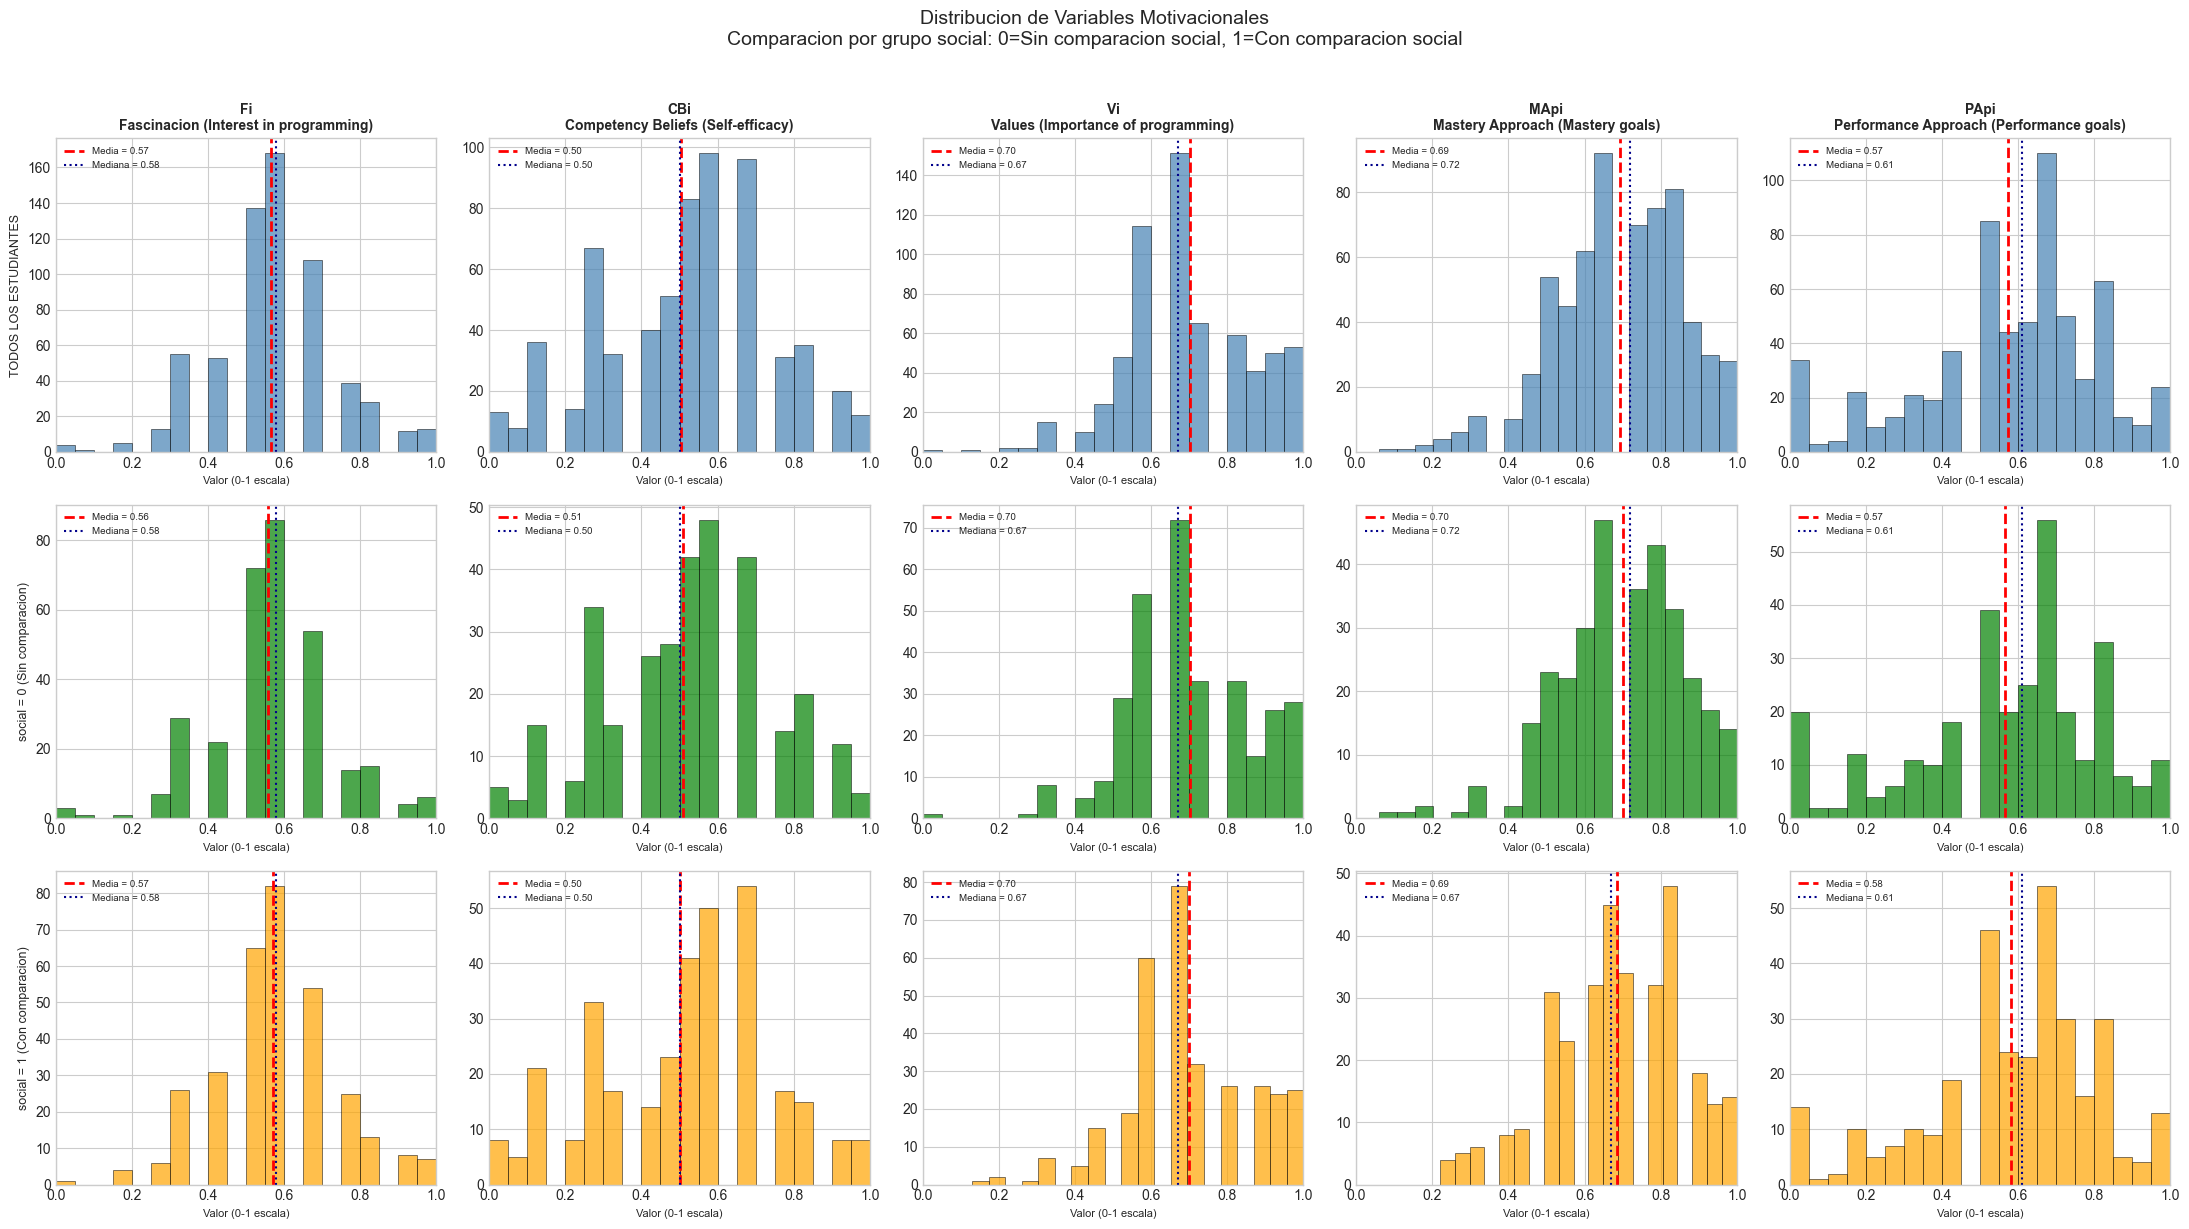

Guardado: dist_motivacionales.png


In [ ]:
# GRAFICO 1: MOTIVACIONALES
motivacionales = ['Fi', 'CBi', 'Vi', 'MApi', 'PApi']
labels = {
    'Fi'   : 'Fascinacion (Interest in programming)',
    'CBi'  : 'Competency Beliefs (Self-efficacy)',
    'Vi'   : 'Values (Importance of programming)',
    'MApi' : 'Mastery Approach (Mastery goals)',
    'PApi' : 'Performance Approach (Performance goals)'
}

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
fig.suptitle(
    'Distribucion de Variables Motivacionales\n'
    'Comparacion por grupo social: 0=Sin comparacion social, 1=Con comparacion social',
    fontsize=14, y=1.02
)

row_labels = ['TODOS LOS ESTUDIANTES', 'social = 0 (Sin comparacion)', 'social = 1 (Con comparacion)']
colors = ['steelblue', 'green', 'orange']

for i, var in enumerate(motivacionales):
    for row_idx, (subset, color, label) in enumerate([
        (data_prep, colors[0], row_labels[0]),
        (data_prep[data_prep['social'] == False], colors[1], row_labels[1]),
        (data_prep[data_prep['social'] == True], colors[2], row_labels[2])
    ]):
        ax = axes[row_idx, i]
        data = subset[var].dropna()
        ax.hist(data, bins=20, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media = {data.mean():.2f}')
        ax.axvline(data.median(), color='darkblue', linestyle=':', linewidth=1.5, label=f'Mediana = {data.median():.2f}')
        if row_idx == 0:
            ax.set_title(var + '\n' + labels.get(var, var), fontsize=10, fontweight='bold')
        if i == 0:
            ax.set_ylabel(label, fontsize=9, rotation=90)
        ax.legend(fontsize=7, loc='upper left')
        ax.set_xlabel('Valor (0-1 escala)', fontsize=8)
        ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('dist_motivacionales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: dist_motivacionales.png')


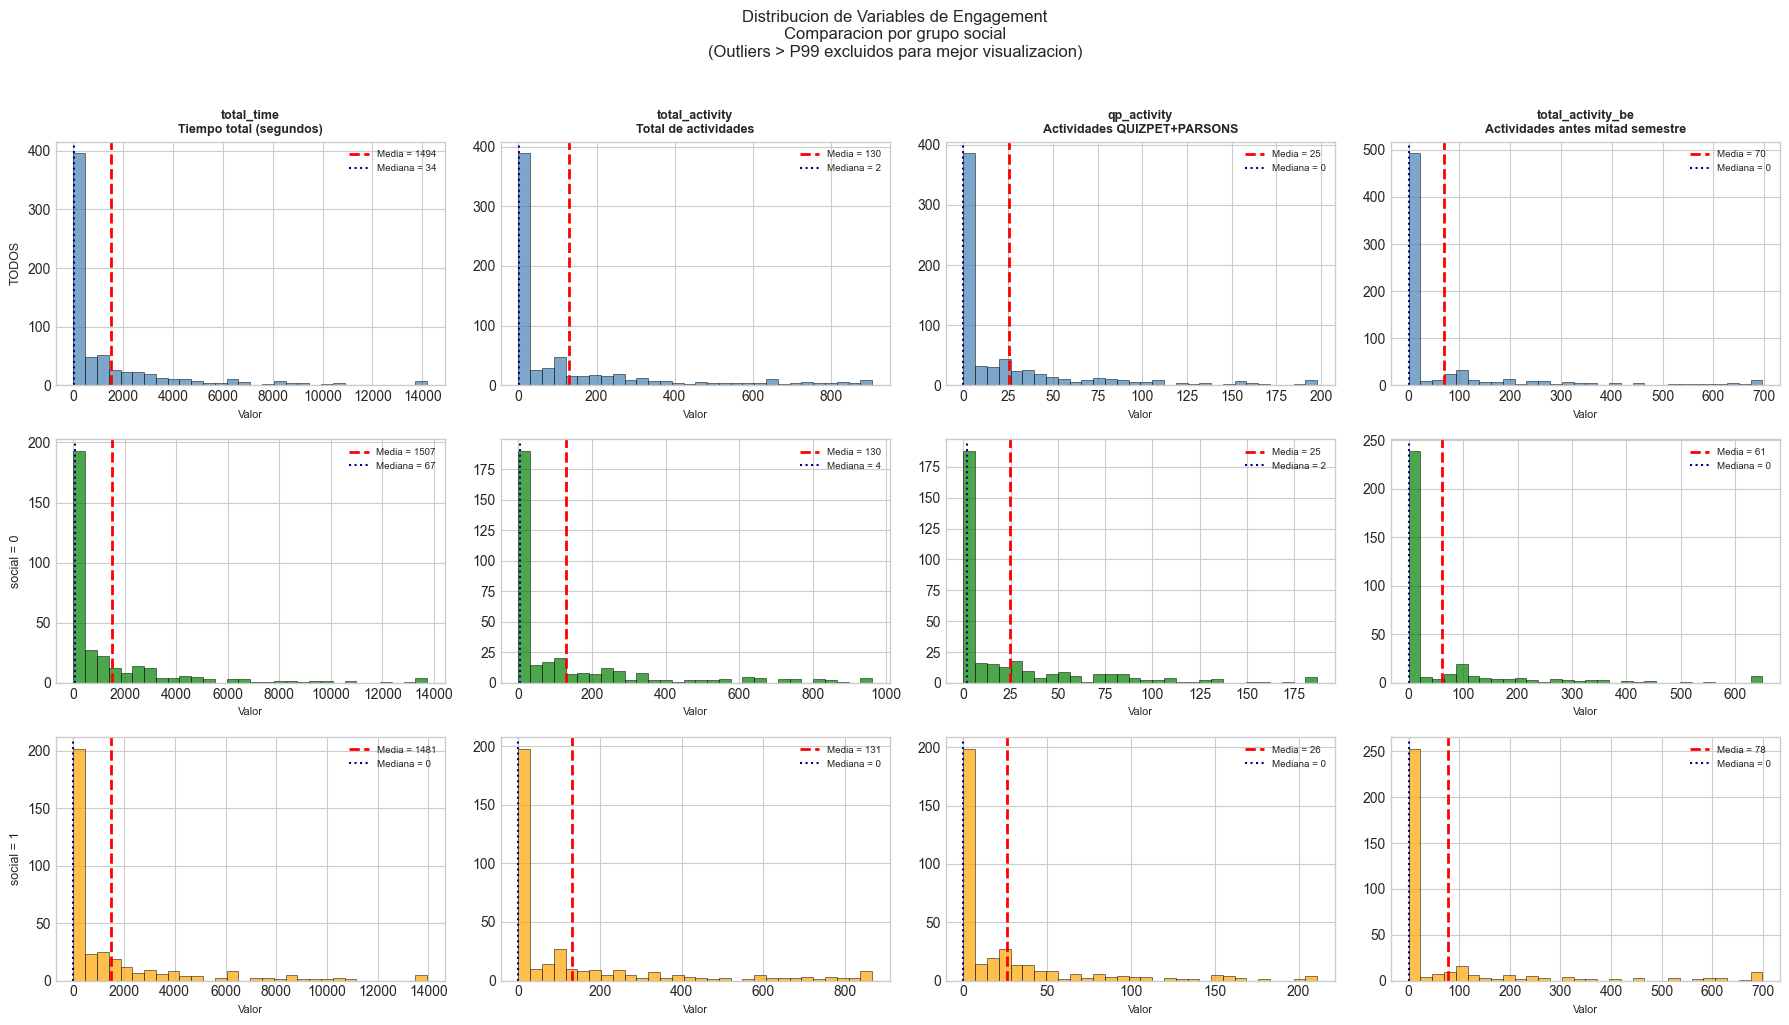

Guardado: dist_engagement.png


In [ ]:
# GRAFICO 2: ENGAGEMENT
engagement_vars = ['total_time', 'total_activity', 'qp_activity', 'total_activity_be']
eng_labels = {
    'total_time'        : 'Tiempo total (segundos)',
    'total_activity'    : 'Total de actividades',
    'qp_activity'       : 'Actividades QUIZPET+PARSONS',
    'total_activity_be' : 'Actividades antes mitad semestre'
}

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
fig.suptitle(
    'Distribucion de Variables de Engagement\n'
    'Comparacion por grupo social\n'
    '(Outliers > P99 excluidos para mejor visualizacion)',
    fontsize=12, y=1.02
)

row_labels = ['TODOS', 'social = 0', 'social = 1']
colors = ['steelblue', 'green', 'orange']

for i, var in enumerate(engagement_vars):
    for row_idx, (subset, color, label) in enumerate([
        (data_prep, colors[0], row_labels[0]),
        (data_prep[data_prep['social'] == False], colors[1], row_labels[1]),
        (data_prep[data_prep['social'] == True], colors[2], row_labels[2])
    ]):
        ax = axes[row_idx, i]
        data = subset[var].dropna()
        q99 = data.quantile(0.99)
        data_clip = data.clip(upper=q99)
        ax.hist(data_clip, bins=30, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media = {data.mean():.0f}')
        ax.axvline(data.median(), color='darkblue', linestyle=':', linewidth=1.5, label=f'Mediana = {data.median():.0f}')
        if row_idx == 0:
            ax.set_title(var + '\n' + eng_labels.get(var, var), fontsize=9, fontweight='bold')
        if i == 0:
            ax.set_ylabel(label, fontsize=9, rotation=90)
        ax.legend(fontsize=7)
        ax.set_xlabel('Valor', fontsize=8)

plt.tight_layout()
plt.savefig('dist_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: dist_engagement.png')


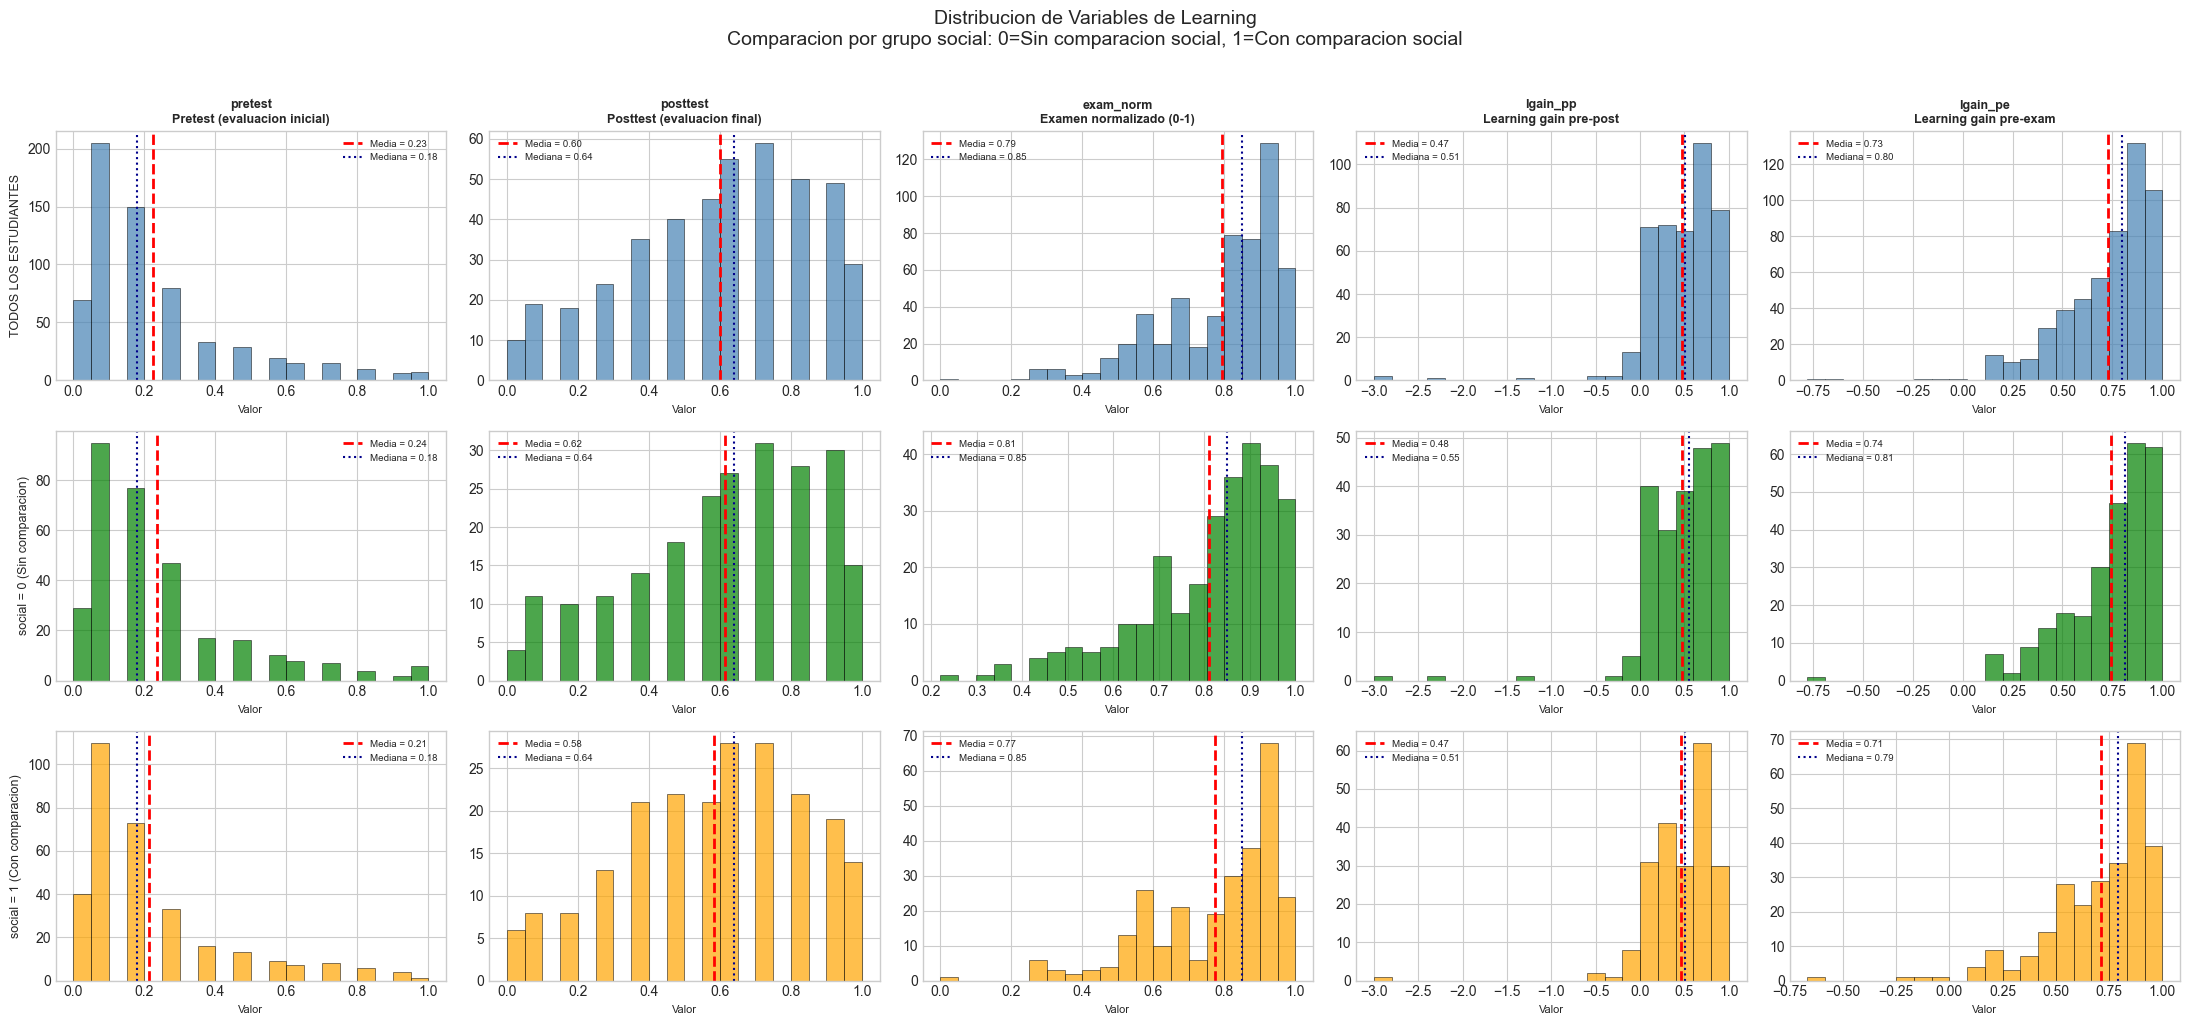

Guardado: dist_learning.png


In [ ]:
# GRAFICO 3: LEARNING
learning_vars = ['pretest', 'posttest', 'exam_norm', 'lgain_pp', 'lgain_pe']
learn_labels = {
    'pretest'   : 'Pretest (evaluacion inicial)',
    'posttest'  : 'Posttest (evaluacion final)',
    'exam_norm ': 'Examen normalizado (0-1)',
    'lgain_pp'  : 'Learning gain pre-post',
    'lgain_pe'  : 'Learning gain pre-exam'
}

fig, axes = plt.subplots(3, 5, figsize=(22, 10))
fig.suptitle(
    'Distribucion de Variables de Learning\n'
    'Comparacion por grupo social: 0=Sin comparacion social, 1=Con comparacion social',
    fontsize=14, y=1.02
)

row_labels = ['TODOS LOS ESTUDIANTES', 'social = 0 (Sin comparacion)', 'social = 1 (Con comparacion)']
colors = ['steelblue', 'green', 'orange']

for i, var in enumerate(learning_vars):
    for row_idx, (subset, color, label) in enumerate([
        (data_prep, colors[0], row_labels[0]),
        (data_prep[data_prep['social'] == False], colors[1], row_labels[1]),
        (data_prep[data_prep['social'] == True], colors[2], row_labels[2])
    ]):
        ax = axes[row_idx, i]
        data = subset[var].dropna()
        ax.hist(data, bins=20, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media = {data.mean():.2f}')
        ax.axvline(data.median(), color='darkblue', linestyle=':', linewidth=1.5, label=f'Mediana = {data.median():.2f}')
        if row_idx == 0:
            ax.set_title(var + '\n' + learn_labels.get(var, var), fontsize=9, fontweight='bold')
        if i == 0:
            ax.set_ylabel(label, fontsize=9, rotation=90)
        ax.legend(fontsize=7)
        ax.set_xlabel('Valor', fontsize=8)

plt.tight_layout()
plt.savefig('dist_learning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: dist_learning.png')


---

## Resumen de Variables

| Variable | Dominio | Transformacion |
|----------|---------|----------------|
| student | ID unico | Ninguna |
| grp | G151-G156 | Ninguna |
| take_exam | 0/1/NA | boolean |
| social | 0/1 | boolean |
| gender | 0/1/NA | category |
| pretest | [0,1] | float64, NA blanks |
| posttest | [0,1] | float64, NA blanks |
| exam | -1/0-100/NA | float64 (preserva -1), NA blanks |
| Fi, CBi, Vi, MApi, PApi | [0,1] | float64, NA blanks |
| exam_norm | [0,1] | Calculada: exam/100 |
| lgain_pp | [-1,1] | Calculada: (post-pre)/(1-pre) |
| lgain_pe | [-1,1] | Calculada: (exam_norm-pre)/(1-pre) |
| total_time | [0,inf) | Suma de duration clipped |
| total_activity | [0,inf) | Conteo de actividades |
| qp_activity | [0,inf) | Conteo QUIZPET+PARSONS |
| total_activity_be | [0,inf) | Conteo antes mitad semestre |

**Nota:** Estudiantes sin actividad en plataforma tienen engagement=0 (cero real, no NA)